In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("Fetching the IBM HR Dataset from a new source...")

# NEW Working URL for the IBM HR Attrition dataset
url = "https://raw.githubusercontent.com/nelson-wu/employee-attrition-ml/master/WA_Fn-UseC_-HR-Employee-Attrition.csv"

# Read the data
df = pd.read_csv(url)

# Split the data: 80% for training, 20% for validation
train_df, validate_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Attrition'])

# Save them as the exact CSV files your project needs
train_df.to_csv('train_hr_data.csv', index=False)
validate_df.to_csv('validate_hr_data.csv', index=False)

print("✅ Success! 'train_hr_data.csv' and 'validate_hr_data.csv' have been created and saved in your folder.")


Fetching the IBM HR Dataset from a new source...
✅ Success! 'train_hr_data.csv' and 'validate_hr_data.csv' have been created and saved in your folder.


In [8]:
import pandas as pd
import xgboost
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore') # Hides annoying red warning messages

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from openpyxl import load_workbook
from openpyxl.styles import PatternFill

print("✅ All tools loaded successfully!")

✅ All tools loaded successfully!


In [9]:
print("========== 1. DATA LOADING ==========")
train_df = pd.read_csv('train_hr_data.csv')
validate_df = pd.read_csv('validate_hr_data.csv')

# Clean up column names just in case
train_df.columns = train_df.columns.str.strip()
validate_df.columns = validate_df.columns.str.strip()

print("Training data shape:", train_df.shape)
print("Validation data shape:", validate_df.shape)

# Convert 'Yes'/'No' to 1 and 0 so the AI can do math on it
train_df['Attrition'] = train_df['Attrition'].map({'Yes': 1, 'No': 0})
print("✅ Data Loaded!")

========== 1. DATA LOADING ==========
Training data shape: (1176, 35)
Validation data shape: (294, 35)
✅ Data Loaded!


========== 2. EXPLORATORY DATA ANALYSIS ==========
Overall Attrition Rate: 16.16 %


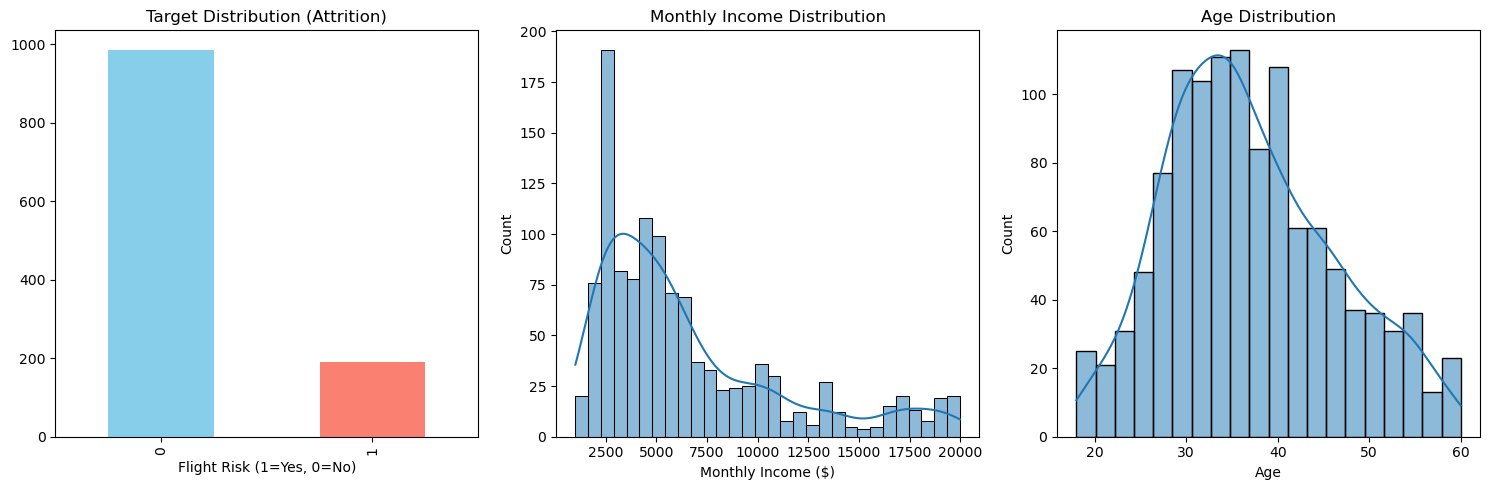

In [10]:
print("========== 2. EXPLORATORY DATA ANALYSIS ==========")
print("Overall Attrition Rate:", round(train_df['Attrition'].mean() * 100, 2), "%")

plt.figure(figsize=(15, 5))

# Chart 1: Target Distribution
plt.subplot(1, 3, 1)
train_df['Attrition'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Target Distribution (Attrition)")
plt.xlabel("Flight Risk (1=Yes, 0=No)")

# Chart 2: Income Distribution
plt.subplot(1, 3, 2)
sns.histplot(train_df['MonthlyIncome'], bins=30, kde=True)
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income ($)")

# Chart 3: Age Distribution
plt.subplot(1, 3, 3)
sns.histplot(train_df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")

plt.tight_layout()
plt.show()

In [11]:
print("========== 3. HR & RETENTION INSIGHTS ==========")

print("\nAverage Monthly Income:")
print(train_df.groupby('Attrition')['MonthlyIncome'].mean())

print("\nAverage Distance From Home (Miles):")
print(train_df.groupby('Attrition')['DistanceFromHome'].mean())

print("\nAverage Years at Company:")
print(train_df.groupby('Attrition')['YearsAtCompany'].mean())

========== 3. HR & RETENTION INSIGHTS ==========

Average Monthly Income:
Attrition
0    6871.638945
1    4843.878947
Name: MonthlyIncome, dtype: float64

Average Distance From Home (Miles):
Attrition
0     9.046653
1    10.973684
Name: DistanceFromHome, dtype: float64

Average Years at Company:
Attrition
0    7.464503
1    4.900000
Name: YearsAtCompany, dtype: float64


In [12]:
print("========== 4. FEATURE ENGINEERING ==========")

def engineer_features(df):
    df = df.copy()
    # Create custom HR metrics
    df['Income_per_Age'] = df['MonthlyIncome'] / (df['Age'] + 1e-6)
    df['Tenure_to_Age_Ratio'] = df['YearsAtCompany'] / (df['Age'] + 1e-6)
    df['Total_Satisfaction'] = df['JobSatisfaction'] + df['EnvironmentSatisfaction'] + df['RelationshipSatisfaction']
    df['Commute_Impact'] = df['DistanceFromHome'] / (df['WorkLifeBalance'] + 1e-6)
    df['Role_Stagnation_Ratio'] = df['YearsInCurrentRole'] / (df['YearsAtCompany'] + 1e-6)
    
    # Drop useless columns
    for col in ['EmployeeCount', 'StandardHours', 'Over18']:
        if col in df.columns: df.drop(col, axis=1, inplace=True)
    return df

train_df = engineer_features(train_df)
validate_df = engineer_features(validate_df)

feature_cols = [col for col in train_df.columns if col not in ['EmployeeNumber', 'Attrition']]
X = train_df[feature_cols]
y = train_df['Attrition']
X_val = validate_df[feature_cols]

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Total features ready for AI: {len(feature_cols)}")

========== 4. FEATURE ENGINEERING ==========
Total features ready for AI: 35


In [13]:
print("========== 5. MODEL TRAINING ==========")

# Data Scaler setup
if len(categorical_cols) > 0:
    preprocessor = ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])
else:
    preprocessor = ColumnTransformer([('num', SimpleImputer(strategy='median'), numeric_cols)])

# Split training data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

print("Training Models (Random Forest, Logistic Regression, XGBoost)...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

lr_model = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

xgb_model = XGBClassifier(eval_metric='logloss', random_state=42, 
                          scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]))
xgb_model.fit(X_train_scaled, y_train)
print("✅ All Models Trained Successfully!")

========== 5. MODEL TRAINING ==========
Training Models (Random Forest, Logistic Regression, XGBoost)...
✅ All Models Trained Successfully!


========== 6. EVALUATION & IMPORTANCE ==========
AI Accuracy Score:  0.8390
AI F1 Score:        0.5000


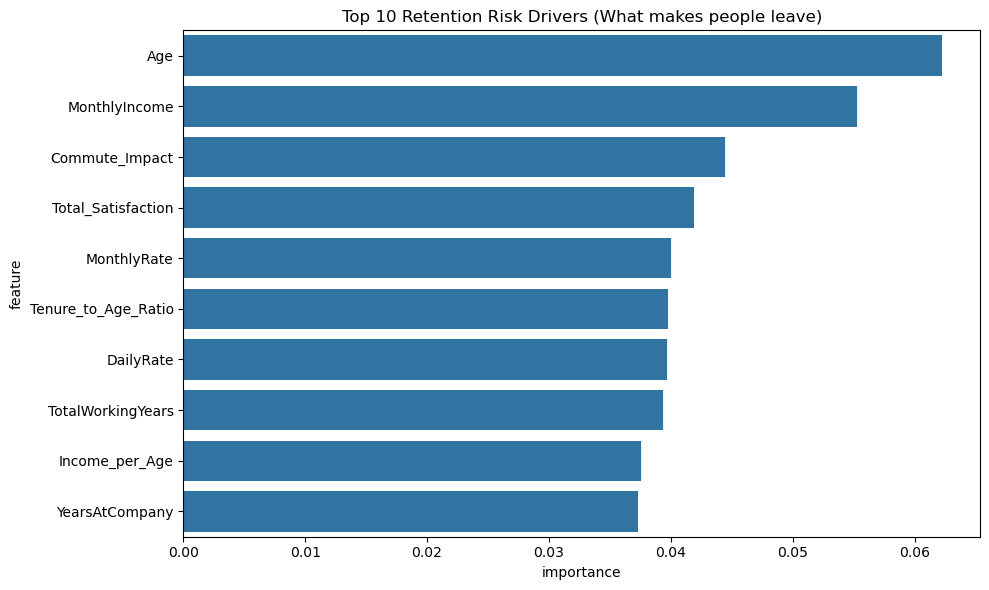

In [14]:
print("========== 6. EVALUATION & IMPORTANCE ==========")

rf_pred = (rf_model.predict_proba(X_test_scaled)[:, 1] >= 0.35).astype(int)
lr_pred = (lr_model.predict_proba(X_test_scaled)[:, 1] >= 0.35).astype(int)
xgb_pred = (xgb_model.predict_proba(X_test_scaled)[:, 1] >= 0.35).astype(int)

# Consensus: If 2 out of 3 models say "they will quit", flag them
consensus_pred = (rf_pred + lr_pred + xgb_pred >= 2).astype(int)

print(f"AI Accuracy Score:  {accuracy_score(y_test, consensus_pred):.4f}")
print(f"AI F1 Score:        {f1_score(y_test, consensus_pred):.4f}")

# Plot what the AI learned
feature_names = numeric_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)) if len(categorical_cols) > 0 else numeric_cols
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Retention Risk Drivers (What makes people leave)')
plt.tight_layout()
plt.show()

In [18]:
print("========== 7. FINAL PREDICTIONS & EXCEL EXPORT ==========")

X_val_processed = preprocessor.transform(X_val)
X_val_scaled = scaler.transform(X_val_processed)

rf_preds = (rf_model.predict_proba(X_val_scaled)[:, 1] >= 0.35).astype(int)
lr_preds = (lr_model.predict_proba(X_val_scaled)[:, 1] >= 0.35).astype(int)
xgb_preds = (xgb_model.predict_proba(X_val_scaled)[:, 1] >= 0.35).astype(int)

consensus = (rf_preds + lr_preds + xgb_preds >= 2).astype(int)

output = pd.DataFrame({
    'EmployeeNumber': validate_df['EmployeeNumber'],
    'Needs_Intervention': consensus
})

print(f"Total employees evaluated: {len(output)}")
print(f"Predicted High Flight Risk: {consensus.sum()}")

excel_path = 'retention_risk_report.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    output.to_excel(writer, index=False)

# Open the Excel file and highlight the "At-Risk" rows in RED
wb = load_workbook(excel_path)
ws = wb.active
red_fill = PatternFill(start_color="FF9999", end_color="FF9999", fill_type="solid")

for row in range(2, ws.max_row + 1):
    if ws[f"B{row}"].value == 1:
        ws[f"A{row}"].fill = red_fill
        ws[f"B{row}"].fill = red_fill

wb.save(excel_path)
print(f"✅ Mission Complete! '{excel_path}' has been saved to your folder.")

========== 7. FINAL PREDICTIONS & EXCEL EXPORT ==========
Total employees evaluated: 294
Predicted High Flight Risk: 37
✅ Mission Complete! 'retention_risk_report.xlsx' has been saved to your folder.
